Data shape: (1250, 83)


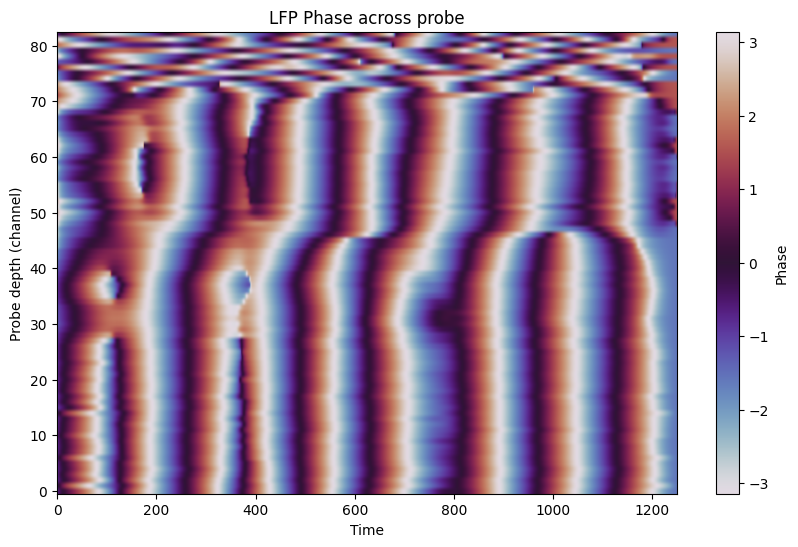

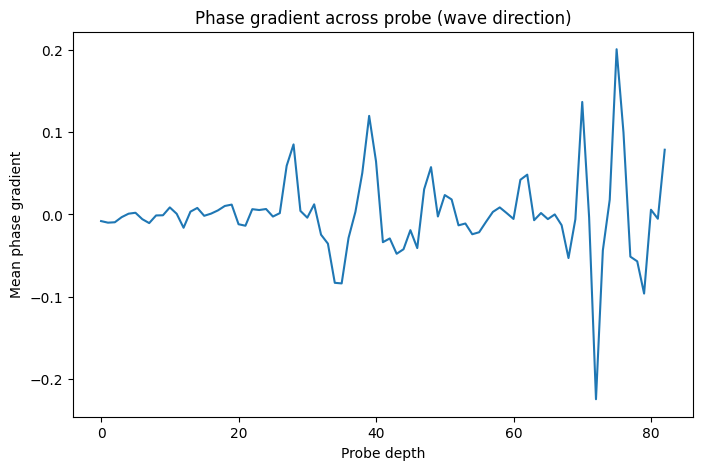

Wave traveling DOWN probe


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, hilbert

# -----------------------------
# Load data
# -----------------------------
lfp = np.load('/home/maria/LFPExperiments/data/1sec_first_data.npy')

print("Data shape:", lfp.shape)

T, D = lfp.shape

# -----------------------------
# Bandpass filter (theta example)
# -----------------------------
fs = 1250   # sampling rate (adjust if different)
low = 4
high = 12

def bandpass(data, low, high, fs, order=4):
    nyq = 0.5 * fs
    b, a = butter(order, [low/nyq, high/nyq], btype='band')
    return filtfilt(b, a, data, axis=0)

lfp_filt = bandpass(lfp, low, high, fs)

# -----------------------------
# Hilbert transform
# -----------------------------
analytic = hilbert(lfp_filt, axis=0)

phase = np.angle(analytic)

# -----------------------------
# Phase gradient across probe
# -----------------------------
phase_grad = np.gradient(phase, axis=1)

mean_grad = np.mean(phase_grad, axis=0)

# -----------------------------
# Plot phase map
# -----------------------------
plt.figure(figsize=(10,6))

plt.imshow(
    phase.T,
    aspect='auto',
    cmap='twilight',
    origin='lower'
)

plt.colorbar(label='Phase')
plt.xlabel("Time")
plt.ylabel("Probe depth (channel)")
plt.title("LFP Phase across probe")

plt.show()

# -----------------------------
# Plot mean phase gradient
# -----------------------------
plt.figure(figsize=(8,5))

plt.plot(mean_grad)
plt.xlabel("Probe depth")
plt.ylabel("Mean phase gradient")
plt.title("Phase gradient across probe (wave direction)")

plt.show()

# -----------------------------
# Estimate wave direction
# -----------------------------
direction = np.sign(np.mean(mean_grad))

if direction > 0:
    print("Wave traveling DOWN probe")
else:
    print("Wave traveling UP probe")

Text(0.5, 0, 'Probe channel')

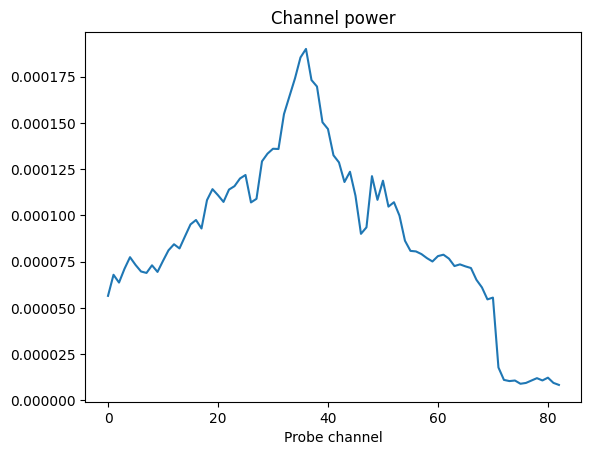

In [2]:
rms = np.sqrt(np.mean(lfp**2, axis=0))

plt.plot(rms)
plt.title("Channel power")
plt.xlabel("Probe channel")

Original shape: (1250, 83)
Cleaned shape: (1250, 71)


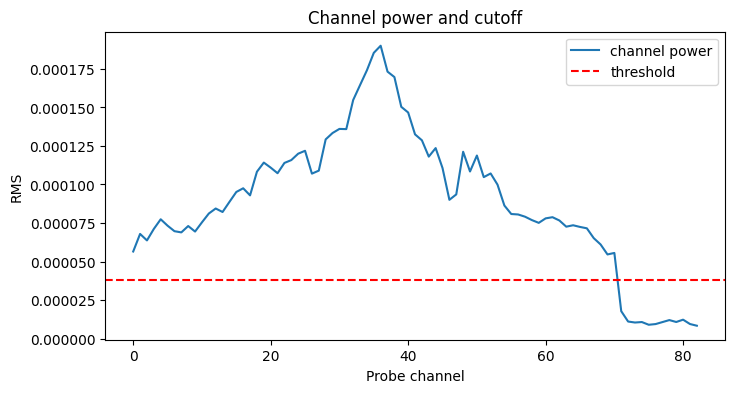

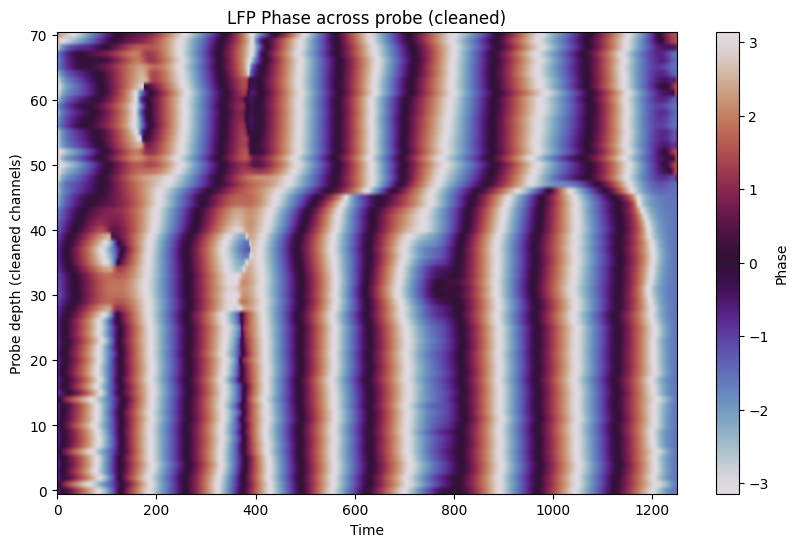

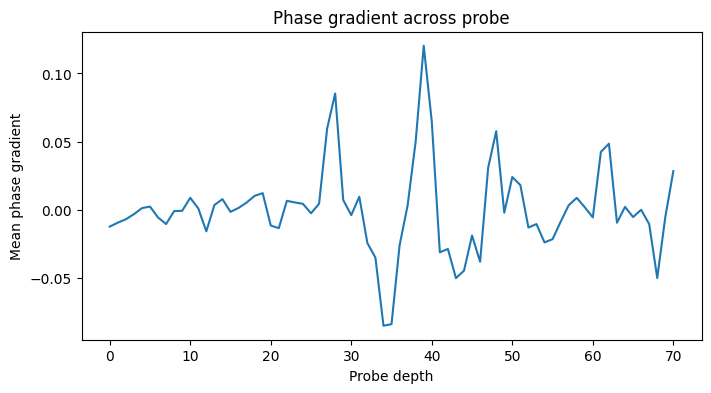

Wave traveling UP probe


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, hilbert

# ---------------------------------------------------
# Load data
# ---------------------------------------------------

lfp = np.load('/home/maria/LFPExperiments/data/1sec_first_data.npy')

print("Original shape:", lfp.shape)

T, D = lfp.shape

# ---------------------------------------------------
# Detect bad channels automatically
# ---------------------------------------------------

rms = np.sqrt(np.mean(lfp**2, axis=0))

threshold = 0.2 * np.max(rms)   # 20% of max power
good_channels = rms > threshold

lfp = lfp[:, good_channels]

print("Cleaned shape:", lfp.shape)

# Plot power for inspection
plt.figure(figsize=(8,4))
plt.plot(rms, label="channel power")
plt.axhline(threshold, color='r', linestyle='--', label="threshold")
plt.title("Channel power and cutoff")
plt.xlabel("Probe channel")
plt.ylabel("RMS")
plt.legend()
plt.show()

# ---------------------------------------------------
# Demean signal
# ---------------------------------------------------

lfp = lfp - np.mean(lfp, axis=0)

# ---------------------------------------------------
# Bandpass filter
# ---------------------------------------------------

fs = 1250
low = 4
high = 12

def bandpass(data, low, high, fs, order=4):

    nyq = 0.5 * fs
    b, a = butter(order, [low/nyq, high/nyq], btype='band')

    return filtfilt(b, a, data, axis=0)

lfp_filt = bandpass(lfp, low, high, fs)

# ---------------------------------------------------
# Hilbert transform
# ---------------------------------------------------

analytic = hilbert(lfp_filt, axis=0)

phase = np.angle(analytic)

# ---------------------------------------------------
# Phase gradient
# ---------------------------------------------------

phase_grad = np.gradient(phase, axis=1)

mean_grad = np.mean(phase_grad, axis=0)

# ---------------------------------------------------
# Plot phase map
# ---------------------------------------------------

plt.figure(figsize=(10,6))

plt.imshow(
    phase.T,
    aspect='auto',
    cmap='twilight',
    origin='lower'
)

plt.colorbar(label='Phase')
plt.xlabel("Time")
plt.ylabel("Probe depth (cleaned channels)")
plt.title("LFP Phase across probe (cleaned)")
plt.show()

# ---------------------------------------------------
# Plot gradient
# ---------------------------------------------------

plt.figure(figsize=(8,4))

plt.plot(mean_grad)

plt.xlabel("Probe depth")
plt.ylabel("Mean phase gradient")
plt.title("Phase gradient across probe")

plt.show()

# ---------------------------------------------------
# Estimate wave direction
# ---------------------------------------------------

direction = np.sign(np.mean(mean_grad))

if direction > 0:
    print("Wave traveling DOWN probe")
else:
    print("Wave traveling UP probe")

Cleaned shape: (1250, 71)


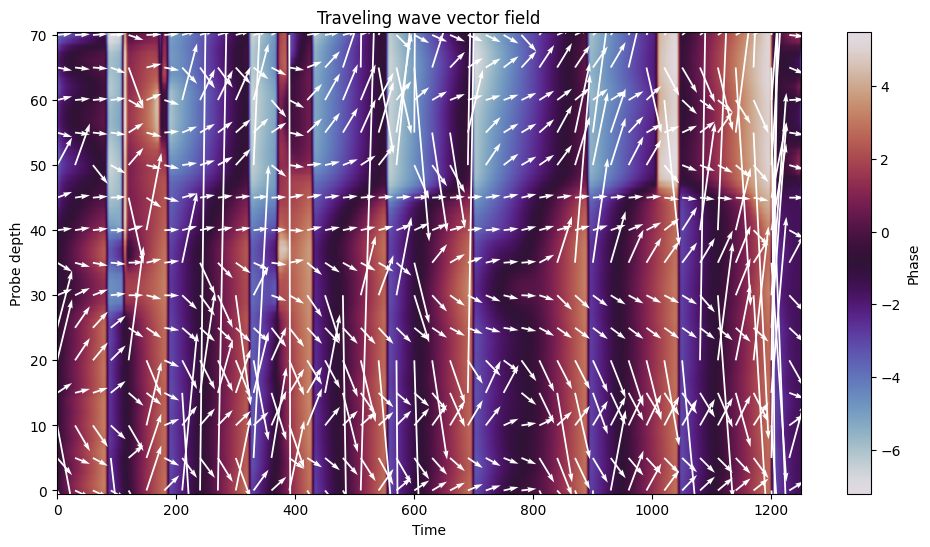

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, hilbert
from scipy.ndimage import gaussian_filter
# ---------------------------------------------------
# Load data
# ---------------------------------------------------

lfp = np.load('/home/maria/LFPExperiments/data/1sec_first_data.npy')

T, D = lfp.shape

# ---------------------------------------------------
# Remove weak channels
# ---------------------------------------------------

rms = np.sqrt(np.mean(lfp**2, axis=0))
threshold = 0.2 * np.max(rms)

good = rms > threshold
lfp = lfp[:, good]

print("Cleaned shape:", lfp.shape)

# ---------------------------------------------------
# Demean
# ---------------------------------------------------

lfp = lfp - np.mean(lfp, axis=0)

# ---------------------------------------------------
# Bandpass
# ---------------------------------------------------

fs = 1250
low = 4
high = 12

def bandpass(data, low, high, fs, order=4):

    nyq = 0.5 * fs
    b, a = butter(order, [low/nyq, high/nyq], btype='band')

    return filtfilt(b, a, data, axis=0)

lfp = bandpass(lfp, low, high, fs)

# ---------------------------------------------------
# Phase extraction
# ---------------------------------------------------

analytic = hilbert(lfp, axis=0)
phase = np.angle(analytic)

# unwrap phase so gradients behave
phase = np.unwrap(phase, axis=1)
phase = gaussian_filter(phase, sigma=(2,1))
# ---------------------------------------------------
# Compute gradients
# ---------------------------------------------------

dphi_dt = np.gradient(phase, axis=0)
dphi_dd = np.gradient(phase, axis=1)

velocity = -dphi_dt / (dphi_dd + 1e-6)

# ---------------------------------------------------
# Subsample grid for plotting arrows
# ---------------------------------------------------

step_t = 30
step_d = 5

T2, D2 = phase.shape

t_idx = np.arange(0, T2, step_t)
d_idx = np.arange(0, D2, step_d)

TT, DD = np.meshgrid(t_idx, d_idx)

U = np.ones_like(TT)          # time direction
V = velocity[TT, DD]          # depth direction

# ---------------------------------------------------
# Plot phase background
# ---------------------------------------------------

plt.figure(figsize=(12,6))

plt.imshow(
    phase.T,
    aspect='auto',
    cmap='twilight',
    origin='lower'
)

plt.colorbar(label="Phase")

# ---------------------------------------------------
# Overlay vector field
# ---------------------------------------------------

plt.quiver(
    TT,
    DD,
    U,
    V,
    color='white',
    scale=50
)

plt.xlabel("Time")
plt.ylabel("Probe depth")
plt.title("Traveling wave vector field")

plt.show()